In [1]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from typing import Annotated
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import Tool
import os
import requests
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
import gradio as gr
from typing import TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv(override = True)

True

In [3]:
serper = GoogleSerperAPIWrapper()

tool_search = Tool(name="search", func=serper.run, description="Use this tool when you need to search the internet, this tool is usefule to search latest information from internet")

In [4]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

tool_push = Tool(name="push", func=push, description="Use this tool when you need to send a push notification to the user")


In [5]:
tools = [tool_search, tool_push]

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [7]:
graph_builder =  StateGraph(State)

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [9]:
def chatbot(state: State):
    print (state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


In [10]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools = tools))

graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=MemorySaver())

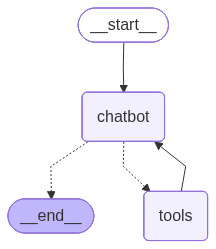

In [16]:

display(Image(graph.get_graph().draw_mermaid_png()))


In [11]:
config = {"configurable": {"thread_id": "1"}}

def chat(input:str,history):
    result = graph.invoke({"messages":[{"role":"user","content": input}]}, config = config)
    return result["messages"][-1].content

In [ ]:
gr.ChatInterface(chat,type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='dbd880f2-7301-4d4d-9ce7-3c7161be6950')]}
{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='dbd880f2-7301-4d4d-9ce7-3c7161be6950'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 104, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eca0ce8298', 'id': 'chatcmpl-ChoP9wrrphjZY3bRfqR1e7FGpzsBn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--7a494c0a-951e-4f9a-8639-a7a838aee111-0', usage_metadata={'input_tokens': 104, 'output_tokens': 10, 'total_tokens': 114, 

In [13]:
graph.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='dbd880f2-7301-4d4d-9ce7-3c7161be6950'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 104, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eca0ce8298', 'id': 'chatcmpl-ChoP9wrrphjZY3bRfqR1e7FGpzsBn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--7a494c0a-951e-4f9a-8639-a7a838aee111-0', usage_metadata={'input_tokens': 104, 'output_tokens': 10, 'total_tokens': 114, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), Human

In [14]:
list(graph.get_state_history(config = config))

[StateSnapshot(values={'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='dbd880f2-7301-4d4d-9ce7-3c7161be6950'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 104, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eca0ce8298', 'id': 'chatcmpl-ChoP9wrrphjZY3bRfqR1e7FGpzsBn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--7a494c0a-951e-4f9a-8639-a7a838aee111-0', usage_metadata={'input_tokens': 104, 'output_tokens': 10, 'total_tokens': 114, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), Huma